# TD3 baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBuffer, collect_episode, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from networks import TD3_Critic
from agents import TD3_Actor

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env


Observation dim: 2, Action dim: 2
[TD3] step=  10001 | train_it=      1 | eval_return=0.000 | eval_len=500.0
[TD3] step=  10002 | train_it=      2 | eval_return=0.125 | eval_len=437.8
[TD3] step=  15000 | train_it=   5000 | eval_return=0.000 | eval_len=500.0
[TD3] step=  20000 | train_it=  10000 | eval_return=0.000 | eval_len=500.0
[TD3] step=  25000 | train_it=  15000 | eval_return=0.000 | eval_len=500.0
[TD3] step=  30000 | train_it=  20000 | eval_return=0.125 | eval_len=438.5
[TD3] step=  35000 | train_it=  25000 | eval_return=0.000 | eval_len=500.0
[TD3] step=  40000 | train_it=  30000 | eval_return=0.000 | eval_len=500.0
[TD3] step=  45000 | train_it=  35000 | eval_return=0.000 | eval_len=500.0
[TD3] step=  50000 | train_it=  40000 | eval_return=0.000 | eval_len=500.0
[TD3] step=  55000 | train_it=  45000 | eval_return=0.250 | eval_len=376.1
[TD3] step=  60000 | train_it=  50000 | eval_return=0.000 | eval_len=500.0
[TD3] step=  65000 | train_it=  55000 | eval_return=0.000 | eval_l

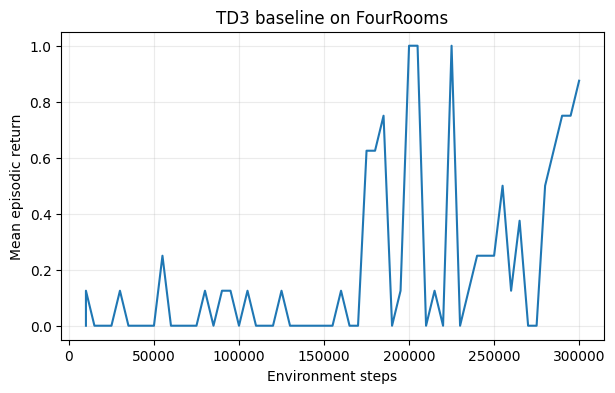

In [3]:
def td3_train(
    total_steps=300000,
    warmup_steps=10000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    policy_noise=0.2,
    noise_clip=0.5,
    policy_delay=2,
    expl_noise=0.15,
    lr=3e-4,
    train_freq=1,
    gradient_steps=1,
    eval_every=5000,
):
    env = make_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    print(f"Observation dim: {obs_dim}, Action dim: {act_dim}")

    actor = TD3_Actor(obs_dim, act_dim).to(DEVICE)
    actor_tgt = TD3_Actor(obs_dim, act_dim).to(DEVICE)
    actor_tgt.load_state_dict(actor.state_dict())

    q1 = TD3_Critic(obs_dim, act_dim).to(DEVICE)
    q2 = TD3_Critic(obs_dim, act_dim).to(DEVICE)
    q1_tgt = TD3_Critic(obs_dim, act_dim).to(DEVICE)
    q2_tgt = TD3_Critic(obs_dim, act_dim).to(DEVICE)
    q1_tgt.load_state_dict(q1.state_dict())
    q2_tgt.load_state_dict(q2.state_dict())

    for p in list(actor_tgt.parameters()) + list(q1_tgt.parameters()) + list(q2_tgt.parameters()):
        p.requires_grad_(False)

    actor_opt = optim.Adam(actor.parameters(), lr=lr)
    critic_opt = optim.Adam(list(q1.parameters()) + list(q2.parameters()), lr=lr)

    replay = TrajectoryReplayBuffer(
        capacity=100000,
        obs_dim=obs_dim,
        action_dim=act_dim,
        device=DEVICE,
    )

    total_env_steps = 0
    train_it = 0
    eval_returns = []
    next_eval_step = eval_every

    obs, _ = env.reset()

    # Warmup: random actions, one step at a time
    while total_env_steps < warmup_steps:
        action = env.action_space.sample().astype(np.float32)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay.add_transition(obs, action, reward, next_obs, done)

        obs = next_obs
        total_env_steps += 1

        if done:
            obs, _ = env.reset()

    # Main loop: one env step at a time
    while total_env_steps < total_steps:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            action_t = actor(obs_t)  # (1, act_dim)

        action = action_t[0].cpu().numpy()
        action = action + np.random.normal(0.0, expl_noise, size=act_dim)
        action = np.clip(action, -1.0, 1.0).astype(np.float32)

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay.add_transition(obs, action, reward, next_obs, done)

        obs = next_obs
        total_env_steps += 1

        if done:
            obs, _ = env.reset()

        if total_env_steps % train_freq == 0:
            for _ in range(gradient_steps):
                batch = replay.sample(batch_size)

                obs_b = batch.obs.float()
                act_b = batch.actions.float()
                rew_b = batch.rewards.float()
                next_obs_b = batch.next_obs.float()
                done_b = torch.clamp(batch.terminated + batch.truncated, 0, 1).float()

                if rew_b.ndim == 1:
                    rew_b = rew_b.unsqueeze(-1)
                if done_b.ndim == 1:
                    done_b = done_b.unsqueeze(-1)

                with torch.no_grad():
                    noise = torch.randn_like(act_b) * policy_noise
                    noise = torch.clamp(noise, -noise_clip, noise_clip)

                    next_a_b = actor_tgt(next_obs_b) + noise
                    next_a_b = torch.clamp(next_a_b, -1.0, 1.0)

                    target_q1 = q1_tgt(next_obs_b, next_a_b)
                    target_q2 = q2_tgt(next_obs_b, next_a_b)
                    target_q = torch.min(target_q1, target_q2)

                    y = rew_b + gamma * (1.0 - done_b) * target_q

                q1_pred = q1(obs_b, act_b)
                q2_pred = q2(obs_b, act_b)
                critic_loss = F.mse_loss(q1_pred, y) + F.mse_loss(q2_pred, y)

                critic_opt.zero_grad()
                critic_loss.backward()
                torch.nn.utils.clip_grad_norm_(list(q1.parameters()) + list(q2.parameters()), 10.0)
                critic_opt.step()

                train_it += 1

                if train_it % policy_delay == 0:
                    actor_loss = -q1(obs_b, actor(obs_b)).mean()

                    actor_opt.zero_grad()
                    actor_loss.backward()
                    torch.nn.utils.clip_grad_norm_(actor.parameters(), 10.0)
                    actor_opt.step()

                    with torch.no_grad():
                        for p, pt in zip(actor.parameters(), actor_tgt.parameters()):
                            pt.data.mul_(1 - tau).add_(tau * p.data)
                        for p, pt in zip(q1.parameters(), q1_tgt.parameters()):
                            pt.data.mul_(1 - tau).add_(tau * p.data)
                        for p, pt in zip(q2.parameters(), q2_tgt.parameters()):
                            pt.data.mul_(1 - tau).add_(tau * p.data)

        if total_env_steps >= next_eval_step:
            eval_env = make_env()

            def eval_actor(o):
                o_t = torch.as_tensor(o, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                with torch.no_grad():
                    a_t = actor(o_t)
                return a_t[0].cpu().numpy().astype(np.float32)

            mean_ret, mean_len = evaluate_policy(
                eval_env,
                eval_actor,
                episodes=8,
            )
            eval_returns.append((total_env_steps, mean_ret))
            print(
                f"[TD3] step={total_env_steps:7d} | "
                f"train_it={train_it:7d} | "
                f"eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}"
            )
            eval_env.close()
            next_eval_step += eval_every

    env.close()
    return actor, q1, eval_returns

td3_actor, td3_q1, td3_eval = td3_train()

if td3_eval:
    xs, ys = zip(*td3_eval)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel("Environment steps")
    plt.ylabel("Mean episodic return")
    plt.title("TD3 baseline on FourRooms")
    plt.grid(alpha=0.25)
    plt.show()

## Visualisations

Episode 1: 38 steps | return: 1.00 | reached goal: True
Episode 2: 40 steps | return: 1.00 | reached goal: True
Episode 3: 30 steps | return: 1.00 | reached goal: True
Episode 4: 32 steps | return: 1.00 | reached goal: True
Episode 5: 32 steps | return: 1.00 | reached goal: True
Episode 6: 500 steps | return: 0.00 | reached goal: False
Episode 7: 30 steps | return: 1.00 | reached goal: True
Episode 8: 16 steps | return: 1.00 | reached goal: True

Success rate: 87.50% over 8 episodes
Average return: 0.88 ± 0.33


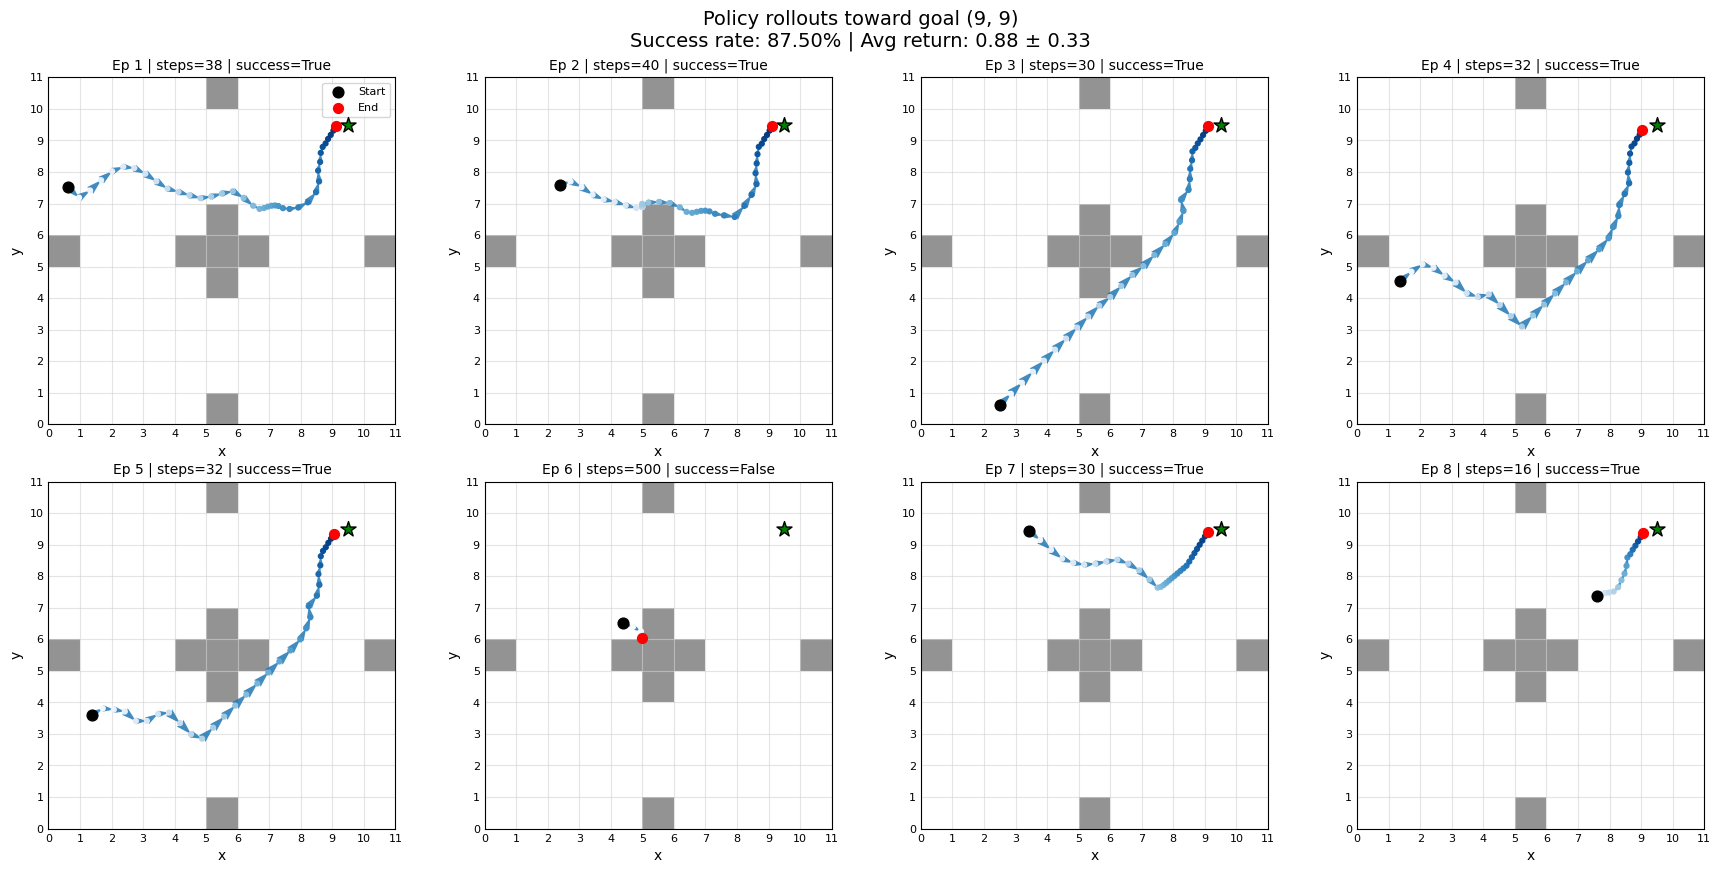

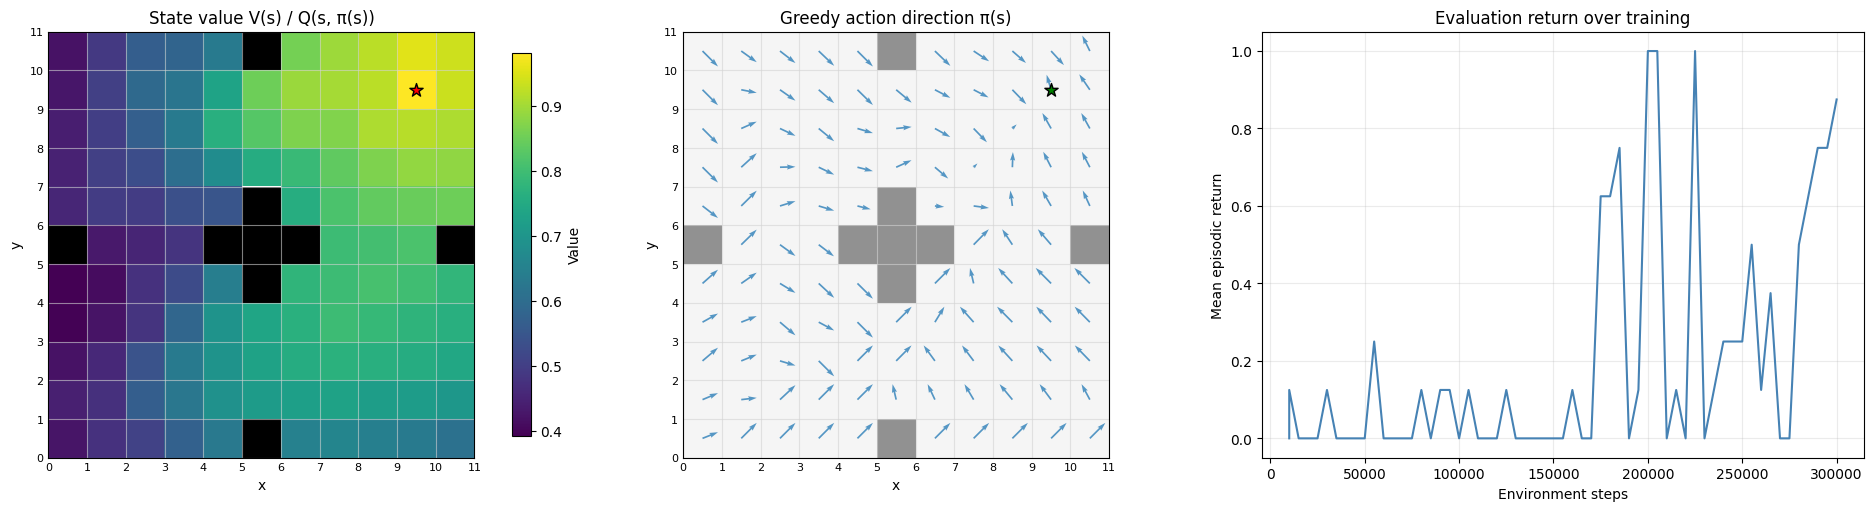

In [4]:

td3_actor.eval()
td3_q1.eval()

eval_env = make_env(goal=(9, 9))


def td3_policy_fn(obs):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        action = td3_actor(obs_t).squeeze(0).cpu().numpy().astype(np.float32)
    return action


def td3_value_fn(obs_batch):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        a = td3_actor(obs_t)
        q = td3_q1(obs_t, a).squeeze(-1).cpu().numpy()
    return q


def td3_actor_fn(obs_batch):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        actions = td3_actor(obs_t).cpu().numpy()
    return actions


plot_policy_rollouts(
    env=eval_env,
    policy_fn=td3_policy_fn,
    goal_pos=(9, 9),
    eval_episodes=8,
    n_cols=4,
    is_discrete=False,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

eval_env.close()

eval_env = make_env(goal=(9, 9))

plot_q_diagnostics(
    env=eval_env,
    value_fn=td3_value_fn,
    actor_fn=td3_actor_fn,
    is_discrete=False,
    goal_pos=(9, 9),
    eval_returns=td3_eval,
)

eval_env.close()